In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

## Dataset Overview

This dataset contains basketball player statistics including performance, shooting accuracy, and game contribution.

Key fields include:
- Player information (name, age, position)
- Game stats (games played, minutes)
- Shooting stats (field goals, 3-points, free throws)
- Performance metrics (points, assists, rebounds)

In [2]:
df = pd.read_csv("../Datasets/NBA.csv")
df

,player,pos,age,bref_team_id,g,gs,mp,fg,fga,fg.,...,drb,trb,ast,stl,blk,tov,pf,pts,season,season_end
0,Quincy Acy,SF,23,TOT,63,0,847,66,141,0.468,...,144,216,28,23,26,30,122,171,2013-2014,2013
1,Steven Adams,C,20,OKC,81,20,1197,93,185,0.503,...,190,332,43,40,57,71,203,265,2013-2014,2013
2,Jeff Adrien,PF,27,TOT,53,12,961,143,275,0.520,...,204,306,38,24,36,39,108,362,2013-2014,2013
3,Arron Afflalo,SG,28,ORL,73,73,2552,464,1011,0.459,...,230,262,248,35,3,146,136,1330,2013-2014,2013
4,Alexis Ajinca,C,25,NOP,56,30,951,136,249,0.546,...,183,277,40,23,46,63,187,328,2013-2014,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Tony Wroten,SG,20,PHI,72,16,1765,345,808,0.427,...,159,228,217,78,16,204,151,939,2013-2014,2013
477,Nick Young,SG,28,LAL,64,9,1810,387,889,0.435,...,137,166,95,46,12,95,156,1144,2013-2014,2013
478,Thaddeus Young,PF,25,PHI,79,78,2718,582,1283,0.454,...,310,476,182,167,36,165,213,1417,2013-2014,2013
479,Cody Zeller,C,21,CHA,82,3,1416,172,404,0.426,...,235,353,92,40,41,87,170,490,2013-2014,2013


In [3]:
df.columns

Index(['player', 'pos', 'age', 'bref_team_id', 'g', 'gs', 'mp', 'fg', 'fga',
       'fg.', 'x3p', 'x3pa', 'x3p.', 'x2p', 'x2pa', 'x2p.', 'efg.', 'ft',
       'fta', 'ft.', 'orb', 'drb', 'trb', 'ast', 'stl', 'blk', 'tov', 'pf',
       'pts', 'season', 'season_end'],
      dtype='object')

In [4]:
df.dtypes

player           object
pos              object
age               int64
bref_team_id     object
g                 int64
gs                int64
mp                int64
fg                int64
fga               int64
fg.             float64
x3p               int64
x3pa              int64
x3p.            float64
x2p               int64
x2pa              int64
x2p.            float64
efg.            float64
ft                int64
fta               int64
ft.             float64
orb               int64
drb               int64
trb               int64
ast               int64
stl               int64
blk               int64
tov               int64
pf                int64
pts               int64
season           object
season_end        int64
dtype: object

In [9]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('.', '', regex=False)
df.columns = df.columns.str.replace('x3p', 'three_p')
df.columns = df.columns.str.replace('x2p', 'two_p')

In [10]:
df

,player,pos,age,bref_team_id,g,gs,mp,fg,fga,fg,...,drb,trb,ast,stl,blk,tov,pf,pts,season,season_end
0,Quincy Acy,SF,23,TOT,63,0,847,66,141,0.468,...,144,216,28,23,26,30,122,171,2013-2014,2013
1,Steven Adams,C,20,OKC,81,20,1197,93,185,0.503,...,190,332,43,40,57,71,203,265,2013-2014,2013
2,Jeff Adrien,PF,27,TOT,53,12,961,143,275,0.520,...,204,306,38,24,36,39,108,362,2013-2014,2013
3,Arron Afflalo,SG,28,ORL,73,73,2552,464,1011,0.459,...,230,262,248,35,3,146,136,1330,2013-2014,2013
4,Alexis Ajinca,C,25,NOP,56,30,951,136,249,0.546,...,183,277,40,23,46,63,187,328,2013-2014,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Tony Wroten,SG,20,PHI,72,16,1765,345,808,0.427,...,159,228,217,78,16,204,151,939,2013-2014,2013
477,Nick Young,SG,28,LAL,64,9,1810,387,889,0.435,...,137,166,95,46,12,95,156,1144,2013-2014,2013
478,Thaddeus Young,PF,25,PHI,79,78,2718,582,1283,0.454,...,310,476,182,167,36,165,213,1417,2013-2014,2013
479,Cody Zeller,C,21,CHA,82,3,1416,172,404,0.426,...,235,353,92,40,41,87,170,490,2013-2014,2013


In [11]:
df.columns

Index(['player', 'pos', 'age', 'bref_team_id', 'g', 'gs', 'mp', 'fg', 'fga',
       'fg', 'three_p', 'three_pa', 'three_p', 'two_p', 'two_pa', 'two_p',
       'efg', 'ft', 'fta', 'ft', 'orb', 'drb', 'trb', 'ast', 'stl', 'blk',
       'tov', 'pf', 'pts', 'season', 'season_end'],
      dtype='object')

In [12]:
df.columns[df.columns.duplicated()]

Index(['fg', 'three_p', 'two_p', 'ft'], dtype='object')

In [13]:
df.columns = [
    'player', 'pos', 'age', 'team_id', 'g', 'gs', 'mp',
    'fg', 'fga', 'fg_pct',
    'three_p', 'three_pa', 'three_p_pct',
    'two_p', 'two_pa', 'two_p_pct',
    'efg_pct', 'ft', 'fta', 'ft_pct',
    'orb', 'drb', 'trb', 'ast', 'stl', 'blk',
    'tov', 'pf', 'pts', 'season', 'season_end'
]

In [14]:
df

,player,pos,age,team_id,g,gs,mp,fg,fga,fg_pct,...,drb,trb,ast,stl,blk,tov,pf,pts,season,season_end
0,Quincy Acy,SF,23,TOT,63,0,847,66,141,0.468,...,144,216,28,23,26,30,122,171,2013-2014,2013
1,Steven Adams,C,20,OKC,81,20,1197,93,185,0.503,...,190,332,43,40,57,71,203,265,2013-2014,2013
2,Jeff Adrien,PF,27,TOT,53,12,961,143,275,0.520,...,204,306,38,24,36,39,108,362,2013-2014,2013
3,Arron Afflalo,SG,28,ORL,73,73,2552,464,1011,0.459,...,230,262,248,35,3,146,136,1330,2013-2014,2013
4,Alexis Ajinca,C,25,NOP,56,30,951,136,249,0.546,...,183,277,40,23,46,63,187,328,2013-2014,2013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Tony Wroten,SG,20,PHI,72,16,1765,345,808,0.427,...,159,228,217,78,16,204,151,939,2013-2014,2013
477,Nick Young,SG,28,LAL,64,9,1810,387,889,0.435,...,137,166,95,46,12,95,156,1144,2013-2014,2013
478,Thaddeus Young,PF,25,PHI,79,78,2718,582,1283,0.454,...,310,476,182,167,36,165,213,1417,2013-2014,2013
479,Cody Zeller,C,21,CHA,82,3,1416,172,404,0.426,...,235,353,92,40,41,87,170,490,2013-2014,2013


In [15]:
df.columns

Index(['player', 'pos', 'age', 'team_id', 'g', 'gs', 'mp', 'fg', 'fga',
       'fg_pct', 'three_p', 'three_pa', 'three_p_pct', 'two_p', 'two_pa',
       'two_p_pct', 'efg_pct', 'ft', 'fta', 'ft_pct', 'orb', 'drb', 'trb',
       'ast', 'stl', 'blk', 'tov', 'pf', 'pts', 'season', 'season_end'],
      dtype='object')

##  Important Features

- **pts** → Total points scored (main performance indicator)
- **fg_pct** → Shooting accuracy
- **ast** → Assists (team contribution)
- **trb** → Total rebounds
- **tov** → Turnovers (mistakes)

## Objective

- Identify top performing players
- Analyze shooting efficiency
- Compare performance across seasons
- Understand player contribution to team

In [21]:
df.isnull().sum()

player         0
pos            0
age            0
team_id        0
g              0
gs             0
mp             0
fg             0
fga            0
fg_pct         0
three_p        0
three_pa       0
three_p_pct    0
two_p          0
two_pa         0
two_p_pct      0
efg_pct        0
ft             0
fta            0
ft_pct         0
orb            0
drb            0
trb            0
ast            0
stl            0
blk            0
tov            0
pf             0
pts            0
season         0
season_end     0
dtype: int64

In [17]:
cols = ['fg_pct', 'three_p_pct', 'ft_pct', 'efg_pct']
df[cols] = df[cols].fillna(0)

In [20]:
df['two_p_pct'] = df['two_p_pct'].fillna(0)

In [68]:
df

,player,pos,age,team_id,g,gs,mp,fg,fga,fg_pct,...,orb,drb,trb,ast,stl,blk,tov,pf,pts,season
0,Quincy Acy,SF,23,TOT,63,0,847,66,141,0.468,...,72,144,216,28,23,26,30,122,171,2013-2014
1,Steven Adams,C,20,OKC,81,20,1197,93,185,0.503,...,142,190,332,43,40,57,71,203,265,2013-2014
2,Jeff Adrien,PF,27,TOT,53,12,961,143,275,0.520,...,102,204,306,38,24,36,39,108,362,2013-2014
3,Arron Afflalo,SG,28,ORL,73,73,2552,464,1011,0.459,...,32,230,262,248,35,3,146,136,1330,2013-2014
4,Alexis Ajinca,C,25,NOP,56,30,951,136,249,0.546,...,94,183,277,40,23,46,63,187,328,2013-2014
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
476,Tony Wroten,SG,20,PHI,72,16,1765,345,808,0.427,...,69,159,228,217,78,16,204,151,939,2013-2014
477,Nick Young,SG,28,LAL,64,9,1810,387,889,0.435,...,29,137,166,95,46,12,95,156,1144,2013-2014
478,Thaddeus Young,PF,25,PHI,79,78,2718,582,1283,0.454,...,166,310,476,182,167,36,165,213,1417,2013-2014
479,Cody Zeller,C,21,CHA,82,3,1416,172,404,0.426,...,118,235,353,92,40,41,87,170,490,2013-2014


In [69]:
cat_cols = ['player', 'pos', 'team_id', 'season']

for col in cat_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in player:
['Quincy Acy' 'Steven Adams' 'Jeff Adrien' 'Arron Afflalo' 'Alexis Ajinca'
 'Cole Aldrich' 'LaMarcus Aldridge' 'Lavoy Allen' 'Ray Allen' 'Tony Allen'
 'Al-Farouq Aminu' 'Louis Amundson' 'Chris Andersen' 'Alan Anderson'
 'James Anderson' 'Ryan Anderson' 'Giannis Antetokounmpo'
 'Carmelo Anthony' 'Joel Anthony' 'Pero Antic' 'Trevor Ariza'
 'Hilton Armstrong' 'Darrell Arthur' 'Omer Asik' 'D.J. Augustin'
 'Gustavo Ayon' 'Jeff Ayres' 'Chris Babb' 'Luke Babbitt' 'Leandro Barbosa'
 'Jose Barea' 'Andrea Bargnani' 'Harrison Barnes' 'Matt Barnes'
 'Will Barton' 'Brandon Bass' 'Shane Battier' 'Nicolas Batum'
 'Jerryd Bayless' 'Aron Baynes' 'Kent Bazemore' 'Bradley Beal'
 'Michael Beasley' 'Marco Belinelli' 'Anthony Bennett' 'Patrick Beverley'
 'Andris Biedrins' 'Chauncey Billups' 'Bismack Biyombo' 'DeJuan Blair'
 'Steve Blake' 'Andray Blatche' 'Eric Bledsoe' 'Vander Blue'
 'Keith Bogans' 'Andrew Bogut' 'Matt Bonner' 'Trevor Booker'
 'Carlos Boozer' 'Chris Bosh' 'Avery Br

## Unique Values in Categorical Columns

This step identifies all unique values present in categorical columns such as player, position, team, and season.

It helps in understanding the variety and diversity of data.

In [70]:
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())


Value counts for player:
player
Tyler Zeller        1
Elliot Williams     1
Derrick Williams    1
Deron Williams      1
Royce White         1
                   ..
Cole Aldrich        1
Alexis Ajinca       1
Arron Afflalo       1
Jeff Adrien         1
Steven Adams        1
Name: count, Length: 481, dtype: int64

Value counts for pos:
pos
SG    110
SF    100
PF     96
C      90
PG     85
Name: count, dtype: int64

Value counts for team_id:
team_id
TOT    63
NOP    18
OKC    17
LAC    16
LAL    16
UTA    16
POR    15
ATL    15
PHO    15
DAL    15
DET    15
HOU    15
NYK    15
MIA    15
BRK    15
CLE    14
MIN    14
SAS    14
BOS    14
WAS    14
ORL    13
MEM    13
MIL    13
CHA    13
DEN    12
PHI    12
GSW    12
IND    12
CHI    11
TOR    10
SAC     9
Name: count, dtype: int64

Value counts for season:
season
2013-2014    481
Name: count, dtype: int64


## Value Counts of Categorical Columns

This step calculates the frequency of each category in the dataset.

It helps to identify the most common players, positions, teams, and seasons.

In [71]:
df.describe()

,age,g,gs,mp,fg,fga,fg_pct,three_p,three_pa,three_p_pct,...,ft_pct,orb,drb,trb,ast,stl,blk,tov,pf,pts
count,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,...,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000,481.000000
mean,26.509356,53.253638,25.571726,1237.386694,192.881497,424.463617,0.434622,39.613306,110.130977,0.245397,...,0.692380,55.810811,162.817048,218.627859,112.536383,39.280665,24.103950,71.862786,105.869023,516.582121
std,4.198265,25.322711,29.658465,897.258840,171.832793,368.850833,0.102401,50.855639,132.751732,0.176482,...,0.213133,62.101191,145.348116,200.356507,131.019557,34.783590,30.875381,62.701690,71.213627,470.422228
min,19.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,32.000000,0.000000,388.000000,47.000000,110.000000,0.400000,0.000000,3.000000,0.000000,...,0.640000,12.000000,43.000000,55.000000,20.000000,9.000000,4.000000,21.000000,44.000000,115.000000
50%,26.000000,61.000000,10.000000,1141.000000,146.000000,332.000000,0.437000,16.000000,48.000000,0.314607,...,0.750000,35.000000,135.000000,168.000000,65.000000,32.000000,14.000000,58.000000,104.000000,401.000000
75%,29.000000,76.000000,54.000000,2016.000000,307.000000,672.000000,0.479000,68.000000,193.000000,0.366460,...,0.816000,73.000000,230.000000,310.000000,152.000000,60.000000,32.000000,108.000000,158.000000,821.000000
max,39.000000,83.000000,82.000000,3122.000000,849.000000,1688.000000,1.000000,261.000000,615.000000,1.000000,...,1.000000,440.000000,783.000000,1114.000000,721.000000,191.000000,219.000000,295.000000,273.000000,2593.000000


In [72]:
corr = df.corr(numeric_only=True)
corr

,age,g,gs,mp,fg,fga,fg_pct,three_p,three_pa,three_p_pct,...,ft_pct,orb,drb,trb,ast,stl,blk,tov,pf,pts
age,1.000000,-0.012074,0.025163,0.007961,-0.009749,-0.018304,0.017929,0.050611,0.028850,0.012090,...,0.005692,-0.068726,0.010822,-0.013451,0.019216,-0.028315,-0.017398,-0.030789,-0.028221,-0.011910
g,-0.012074,1.000000,0.610951,0.864487,0.739993,0.746963,0.342499,0.518074,0.537011,0.243597,...,0.440999,0.546902,0.707389,0.682688,0.551128,0.709650,0.475581,0.713508,0.865797,0.728462
gs,0.025163,0.610951,1.000000,0.860036,0.821619,0.811531,0.240620,0.501808,0.515718,0.162971,...,0.249641,0.560067,0.774892,0.735738,0.636059,0.743178,0.505589,0.767107,0.725573,0.810294
mp,0.007961,0.864487,0.860036,1.000000,0.931120,0.936883,0.286372,0.645056,0.666126,0.276297,...,0.386839,0.576844,0.821145,0.774492,0.733041,0.852331,0.506254,0.885406,0.884484,0.927464
fg,-0.009749,0.739993,0.821619,0.931120,1.000000,0.988262,0.286553,0.597239,0.613988,0.239951,...,0.355072,0.562293,0.820259,0.769339,0.708228,0.786597,0.484208,0.903383,0.798769,0.992041
fga,-0.018304,0.746963,0.811531,0.936883,0.988262,1.000000,0.222932,0.662004,0.685535,0.289914,...,0.382954,0.487154,0.771821,0.710910,0.748141,0.803290,0.412738,0.910689,0.786560,0.989211
fg_pct,0.017929,0.342499,0.240620,0.286372,0.286553,0.222932,1.000000,-0.010666,-0.025327,-0.082476,...,0.184496,0.422362,0.381352,0.407564,0.080506,0.197596,0.399377,0.232955,0.370017,0.257634
three_p,0.050611,0.518074,0.501808,0.645056,0.597239,0.662004,-0.010666,1.000000,0.991700,0.539664,...,0.374845,-0.065822,0.280171,0.182848,0.617553,0.592092,-0.043707,0.560520,0.446711,0.655342
three_pa,0.028850,0.537011,0.515718,0.666126,0.613988,0.685535,-0.025327,0.991700,1.000000,0.538397,...,0.381336,-0.058075,0.291838,0.193712,0.643211,0.622973,-0.040987,0.589799,0.463455,0.672076
three_p_pct,0.012090,0.243597,0.162971,0.276297,0.239951,0.289914,-0.082476,0.539664,0.538397,1.000000,...,0.346851,-0.235295,0.012785,-0.063656,0.330362,0.288919,-0.147881,0.230831,0.105314,0.272773


##  Note on Season_End Column

The 'season_end' column shows NaN values in correlation analysis because it has limited variation or does not contribute meaningful numerical relationships.

Hence, it is not considered for correlation analysis.

##  Correlation Analysis

Correlation shows the relationship between numerical variables.
This helps identify which features are related to each other.

In [74]:
team_analysis = df.groupby('team_id')['pts'].agg(['mean','sum'])
print(team_analysis)

               mean    sum
team_id                   
ATL      529.866667   7948
BOS      476.142857   6666
BRK      506.066667   7591
CHA      535.384615   6960
CHI      567.000000   6237
CLE      473.785714   6633
DAL      573.133333   8597
DEN      639.833333   7678
DET      552.400000   8286
GSW      655.833333   7870
HOU      559.000000   8385
IND      612.083333   7345
LAC      536.375000   8582
LAL      485.562500   7769
MEM      542.461538   7052
MIA      548.933333   8234
MIL      476.461538   6194
MIN      609.142857   8528
NOP      451.222222   8122
NYK      523.200000   7848
OKC      499.529412   8492
ORL      561.769231   7303
PHI      462.916667   5555
PHO      575.266667   8629
POR      583.533333   8753
SAC      565.555556   5090
SAS      602.642857   8437
TOR      642.100000   6421
TOT      341.301587  21502
UTA      486.125000   7778
WAS      570.785714   7991


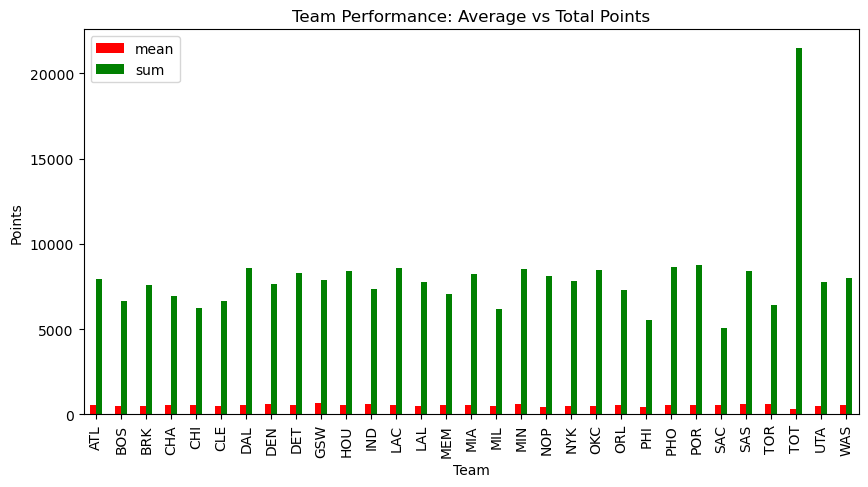

In [75]:
team_analysis.plot(
    kind='bar',
    figsize=(10,5),
    color=['red', 'green']
)

plt.title('Team Performance: Average vs Total Points')
plt.xlabel('Team')
plt.ylabel('Points')
plt.xticks(rotation=90)

plt.show()

## Team Performance Analysis

This analysis combines both average and total points scored by each team.
This helps in comparing team efficiency and total scoring together.

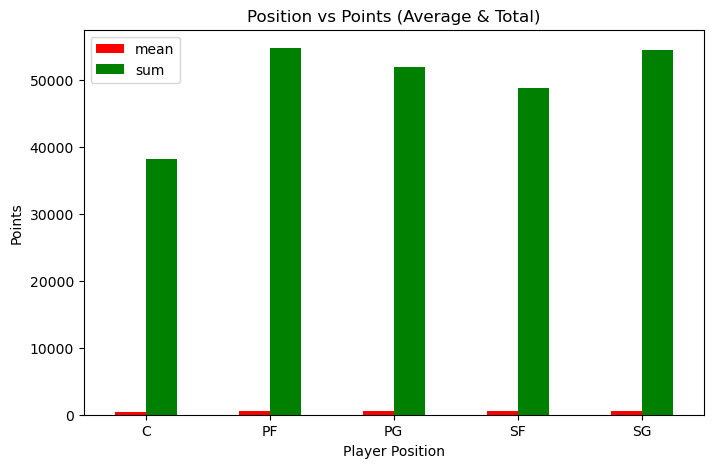

In [76]:
pos_analysis = df.groupby('pos')['pts'].agg(['mean', 'sum'])

pos_analysis.plot(kind='bar',figsize=(8,5),color=['red', 'green'])
plt.title('Position vs Points (Average & Total)')
plt.xlabel('Player Position')
plt.ylabel('Points')
plt.xticks(rotation=0)

plt.show()

## Key Insights

- **PF & SG** have the highest total points (~55k).
- **PG** also performs strong (~52k).
- **SF** is slightly lower (~49k).
- **C** has the lowest total (~38k).
- **PG, SG, PF** have higher average points.
- **F & G** show no significant data.

Scoring is dominated by **guards and forwards**, while **centers contribute less**.

In [77]:
player_pts = df.groupby('player')['pts'].sum().nlargest(10)
print(player_pts)

player
Kevin Durant       2593
Carmelo Anthony    2112
LeBron James       2089
Kevin Love         2010
Blake Griffin      1930
Stephen Curry      1873
James Harden       1851
DeMar DeRozan      1791
Paul George        1737
Dirk Nowitzki      1735
Name: pts, dtype: int64


## Top 10 Players by Total Points

This analysis identifies the top 10 players based on total points scored.

It highlights the highest-performing players who contributed the most in terms of scoring.

Top 10 Players by Assists:
 player
John Wall           721
Ricky Rubio         704
Stephen Curry       666
Chris Paul          663
Brandon Jennings    609
Kyle Lowry          586
Ty Lawson           543
Jeff Teague         528
LeBron James        488
Kendall Marshall    477
Name: ast, dtype: int64


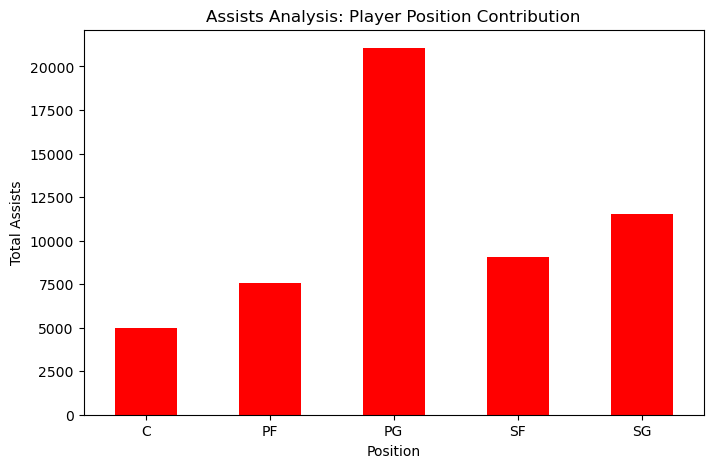

In [78]:
player_ast = df.groupby('player')['ast'].sum().nlargest(10)
print("Top 10 Players by Assists:\n", player_ast)

pos_ast = df.groupby('pos')['ast'].sum()
pos_ast.plot(kind='bar',figsize=(8,5),color='red')

plt.title('Assists Analysis: Player Position Contribution')
plt.xlabel('Position')
plt.ylabel('Total Assists')
plt.xticks(rotation=0)

plt.show()

### Top Players (Assists)
- **John Wall (721)** → highest assists
- **Ricky Rubio (704)**, **Stephen Curry (666)**, **Chris Paul (663)** → strong playmakers
- Most top players are **Point Guards**

## Assists Analysis – Key Insights
- **Point Guard (PG)** has the highest assists (~21k) → main playmaker role.
- **Shooting Guard (SG)** and **Small Forward (SF)** contribute moderately.
- **Power Forward (PF)** has lower assists (~7.5k).
- **Center (C)** has the least (~5k).
- 
- Assists are dominated by **Point Guards**, showing they control game play.
- Other positions contribute less in playmaking.

In [79]:
player_trb = df.groupby('player')['trb'].sum().nlargest(10)
print(player_trb)

player
DeAndre Jordan       1114
Andre Drummond       1071
Kevin Love            963
Joakim Noah           900
Dwight Howard         866
DeMarcus Cousins      831
Zach Randolph         795
Al Jefferson          792
Marcin Gortat         767
LaMarcus Aldridge     765
Name: trb, dtype: int64


## Rebounds Analysis – Top Players Insights

- **DeAndre Jordan (1114)** → highest rebounds
- **Andre Drummond (1071)** and **Kevin Love (963)** also dominate
- Most players are **Centers (C)** and **Power Forwards (PF)**

### Key Pattern
- Rebounding is dominated by **big players (C & PF)**
- Guards are not present → less involvement in rebounds

- **Centers and Power Forwards** are the main rebound contributors due to size and positioning.

In [80]:
pivot1 = pd.pivot_table(
    df,
    values='pts',
    index='team_id',
    columns='season',
    aggfunc='sum'
)
pivot1

season,2013-2014
team_id,
ATL,7948
BOS,6666
BRK,7591
CHA,6960
CHI,6237
CLE,6633
DAL,8597
DEN,7678
DET,8286


## Pivot Table (2013–2014 Season) – Key Insights

- **POR (8753)** and **PHO (8629)** have the highest values.
- **DAL (8597)** and **LAC (8582)** also perform strongly.
- **SAC (5090)** and **PHI (5555)** have the lowest values.
- Most teams fall in the **7000–8500 range**.

### Key Pattern
- Top teams show consistently high performance.
- Few teams significantly lag behind.

- **Portland and Phoenix** lead the season, while **Sacramento and Philadelphia** underperform.

In [81]:
pivot2 = pd.pivot_table(
    df,
    values='mp',
    index='pos',
    columns='team_id',
    aggfunc='mean'
)

pivot2

team_id,ATL,BOS,BRK,CHA,CHI,CLE,DAL,DEN,DET,GSW,...,ORL,PHI,PHO,POR,SAC,SAS,TOR,TOT,UTA,WAS
pos,,,,,,,,,,,,,,,,,,,,,
C,401.25,944.000000,604.666667,1680.333333,1148.000000,1424.50,945.666667,924.500000,1468.000000,735.000000,...,1500.00,251.0,795.000000,1228.333333,1186.000000,1306.666667,2282.000000,670.222222,872.333333,1209.333333
PF,1575.75,1894.333333,1250.000000,1222.666667,2246.000000,2594.00,1921.000000,1521.333333,922.500000,1585.500000,...,899.25,1160.0,1520.000000,1685.500000,749.666667,1205.333333,1244.000000,774.250000,1366.666667,1208.000000
PG,1529.50,1328.333333,1023.400000,1428.000000,834.666667,2374.00,1155.500000,1544.000000,1891.000000,2846.000000,...,2333.00,1265.0,930.000000,1644.000000,1697.000000,1762.000000,1504.000000,1136.300000,1002.750000,2980.000000
SF,2341.00,1670.000000,1755.666667,1049.000000,2584.000000,462.75,1831.500000,1292.333333,1768.333333,2013.666667,...,1950.00,1742.0,1496.000000,1374.666667,1065.000000,1969.500000,322.000000,950.687500,2074.000000,1362.250000
SG,1283.00,67.333333,2575.000000,1370.000000,1911.000000,874.40,1216.750000,1994.000000,1016.500000,1505.000000,...,1282.50,1094.0,1843.666667,935.750000,2187.000000,1046.750000,1765.333333,923.500000,927.666667,1092.333333


## Position vs Team Performance – Key Insights

- **SF and PF** show strong contributions across many teams.
- **PG** has high values in some teams (like GSW, WAS) → key playmaker role.
- **C** contribution varies a lot between teams.
- **SG** performance is inconsistent (very high in some, very low in others).

### Key Pattern
- Different teams rely on **different positions** for performance.
- No single position dominates all teams.

- Team strategy differs: some depend on **forwards (SF/PF)**, others on **guards (PG/SG)**.

In [82]:
pivot3 = pd.pivot_table(
    df,
    values='pts',
    index='player',
    columns='season',
    aggfunc='sum'
)

pivot3

season,2013-2014
player,
A.J. Price,44
Aaron Brooks,645
Aaron Gray,65
Adonis Thomas,14
Al Harrington,225
...,...
Willie Green,273
Wilson Chandler,846
Xavier Henry,432


## Player-wise Performance (481 Players) – Key Insights

- Data includes **481 players**, showing a wide performance range.
- Only a **few players have very high values** (top performers).
- Majority of players have **low to moderate values**.

### Key Pattern
- Performance is **highly uneven** across players.
- **Top players contribute a large share**, while others contribute less.

- Overall performance is **skewed toward a few key players**, indicating strong **player dependency**.

In [83]:
pivot4 = pd.pivot_table(
    df,
    values='player',
    index='team_id',
    columns='pos',
    aggfunc='count'
)

pivot4

pos,C,PF,PG,SF,SG
team_id,,,,,
ATL,4,4,4,1,2
BOS,2,3,3,3,3
BRK,3,3,5,3,1
CHA,3,3,2,3,2
CHI,3,2,3,1,2
CLE,2,1,2,4,5
DAL,3,2,4,2,4
DEN,2,3,2,3,2
DET,2,4,2,3,4


## Team vs Position Count – Key Insights

- **SF and SG (16 each)** have the highest overall counts.
- **PF (12)** and **PG (10)** are moderately represented.
- **C (9)** has the lowest overall count.

### Team Patterns
- Some teams rely more on specific positions:
  - **CLE, LAC** → more **SG/SF**
  - **NYK, NOP** → more **Centers (C)**
  - **PHO** → balanced across all positions

### Key Pattern
- **Guards (SG) and Forwards (SF)** are most common.
- Teams maintain a mix, but few are perfectly balanced.

- Modern teams prefer **SG and SF roles**, while **Centers are fewer** in comparison.

In [86]:
print(df['pos'].unique())

['SF' 'C' 'PF' 'SG' 'PG']


In [87]:
df['pos']=df['pos'].replace({'G':'SG','F':'SF'})

In [93]:
import matplotlib.pyplot as plt
from ipywidgets import interact
def dashboard(team, position):
    
    filtered_df = df[
        (df['team_id'] == team) &
        (df['pos'] == position)
    ]
    
    result = filtered_df.groupby('player')['pts'].sum().sort_values(ascending=False)
    
    result.plot(
        kind='bar',
        figsize=(10,5),
        color='red'
    )
    
    plt.title(f'Player vs Points for {team} - {position}')
    plt.xlabel('Player')
    plt.ylabel('Total Points')
    plt.xticks(rotation=90)
    
    plt.show()
    
interact(
    dashboard,
    team=df['team_id'].unique(),
    position=df['pos'].unique()
)

interactive(children=(Dropdown(description='team', options=('TOT', 'OKC', 'ORL', 'NOP', 'NYK', 'POR', 'MIA', '…

<function __main__.dashboard(team, position)>

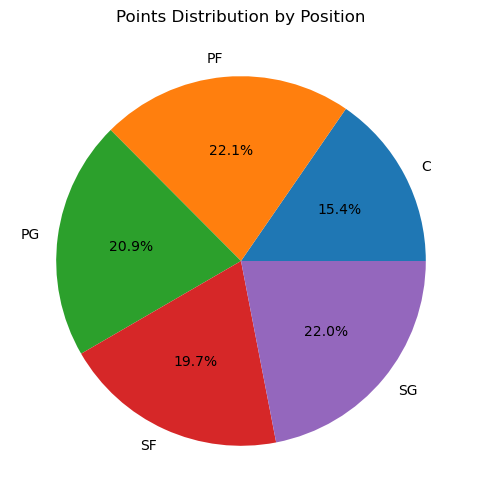

In [94]:
df.groupby('pos')['pts'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)
plt.title('Points Distribution by Position')
plt.ylabel('')
plt.show()

## Points Distribution by Position – Key Insights

- **PF (22.1%)** and **SG (22.0%)** contribute the most points.
- **PG (20.9%)** and **SF (19.7%)** also have strong contributions.
- **C (15.4%)** has the lowest share.

### Key Pattern
- Points are fairly **evenly distributed** among positions except Center.
- **Forwards and Guards dominate scoring**.

- **PF and SG lead scoring**, while **Centers contribute the least**.

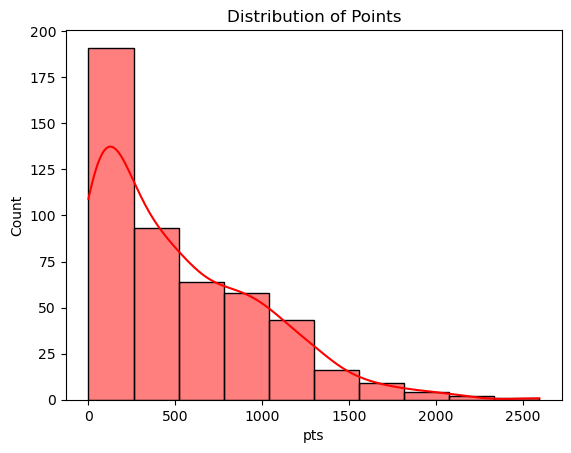

In [96]:
sb.histplot(df['pts'], bins=10, kde=True, color = 'red')
plt.title('Distribution of Points')
plt.show()

## Distribution of Points – Key Insights

- Most players score **low to moderate points (0–500)**.
- Very few players score **very high (>1500)**.
- The graph is **right-skewed** (long tail on the right).

### Key Pattern
- Majority of players have **lower scores**.
- Only a **small number of players are high scorers**.

- Scoring is **not evenly distributed** → dominated by a few top players.

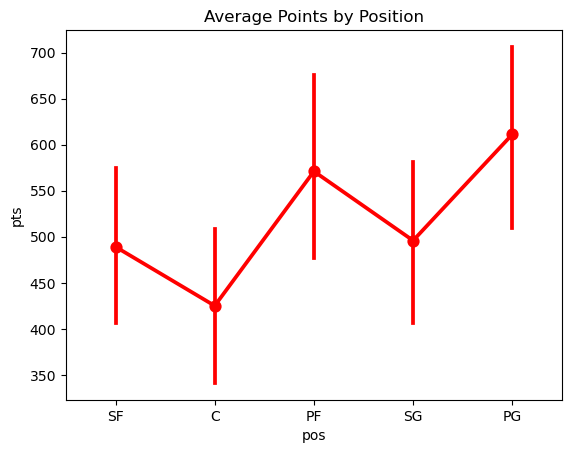

In [98]:
sb.pointplot(x='pos', y='pts', data=df, color = 'red')
plt.title('Average Points by Position')
plt.show()

## Average Points by Position – Key Insights

- **PG (~610)** has the highest average points.
- **PF (~570)** is the second highest.
- **SG (~495)** and **SF (~490)** are moderate.
- **C (~425)** has the lowest average.

### Key Pattern
- **Guards (PG)** score more on average.
- **Centers score the least**.

- **Point Guards lead in scoring efficiency**, while **Centers lag behind**.

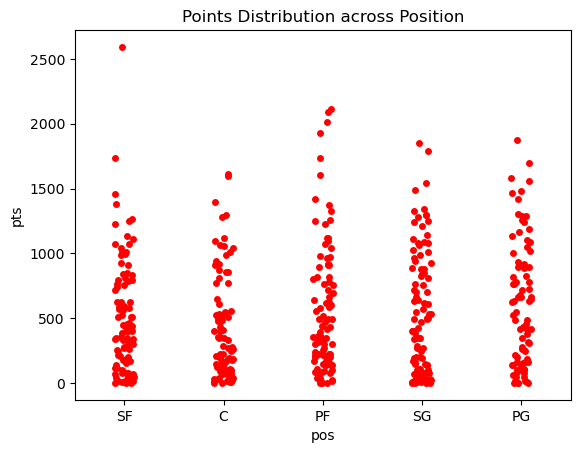

In [100]:
sb.stripplot(x='pos', y='pts', data=df, color='red')
plt.title('Points Distribution across Position')
plt.show()

##  Key Insights (Short)

- Most players score below 1000 points across all positions.
- Small Forwards (SF) have the highest scorers (top outliers).
- Centers (C) generally score the least.
- Guards (SG, PG) show more consistent scoring patterns.
- A few elite players create high outliers in every position.

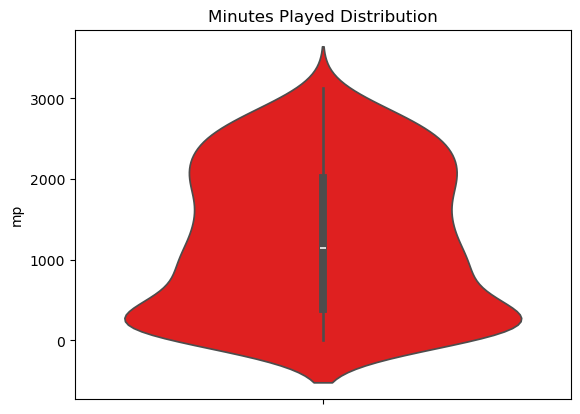

In [101]:
sb.violinplot(y='mp', data=df, color='red')
plt.title('Minutes Played Distribution')
plt.show()

## Key Insights (Minutes Played)

- Most players have low to moderate minutes (below ~1500).
- A smaller group of players play very high minutes (2000+).
- Distribution is wide, showing variation in player roles.
- Many players have limited game time (bench/rotation players).
- Few players dominate with consistently high minutes.

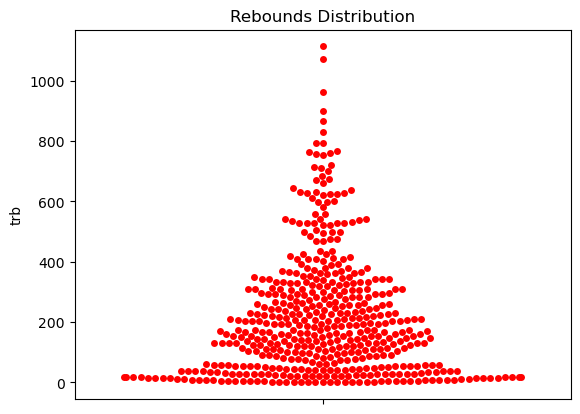

In [102]:
sb.swarmplot(y='trb', data=df, color='red')
plt.title('Rebounds Distribution')
plt.show()

## Key Insights (Rebounds)

- Most players have low rebounds (below ~300).
- Distribution is right-skewed with few high rebounders.
- A small number of players dominate rebounds (800+).
- Majority of players contribute minimally in rebounding.
- High rebound values indicate specialized roles (e.g., big players).

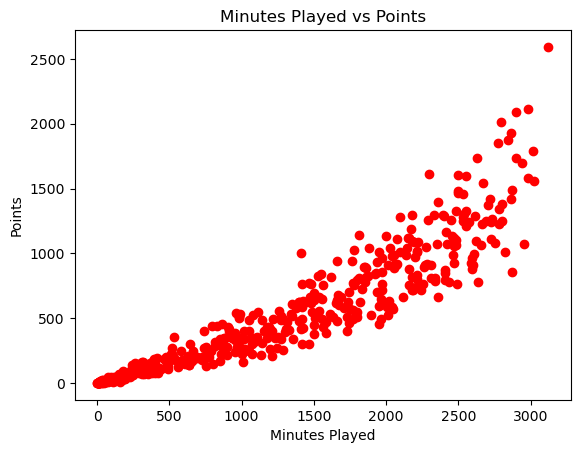

In [104]:
plt.scatter(df['mp'], df['pts'], color='red')
plt.xlabel('Minutes Played')
plt.ylabel('Points')
plt.title('Minutes Played vs Points')
plt.show()

## Key Insights (Minutes Played vs Points)

- Strong positive relationship between minutes played and points scored.
- Players with more minutes tend to score higher.
- Low-minute players consistently have low points.
- Some high-minute players score exceptionally high (outliers).
- Indicates playing time directly impacts scoring performance.

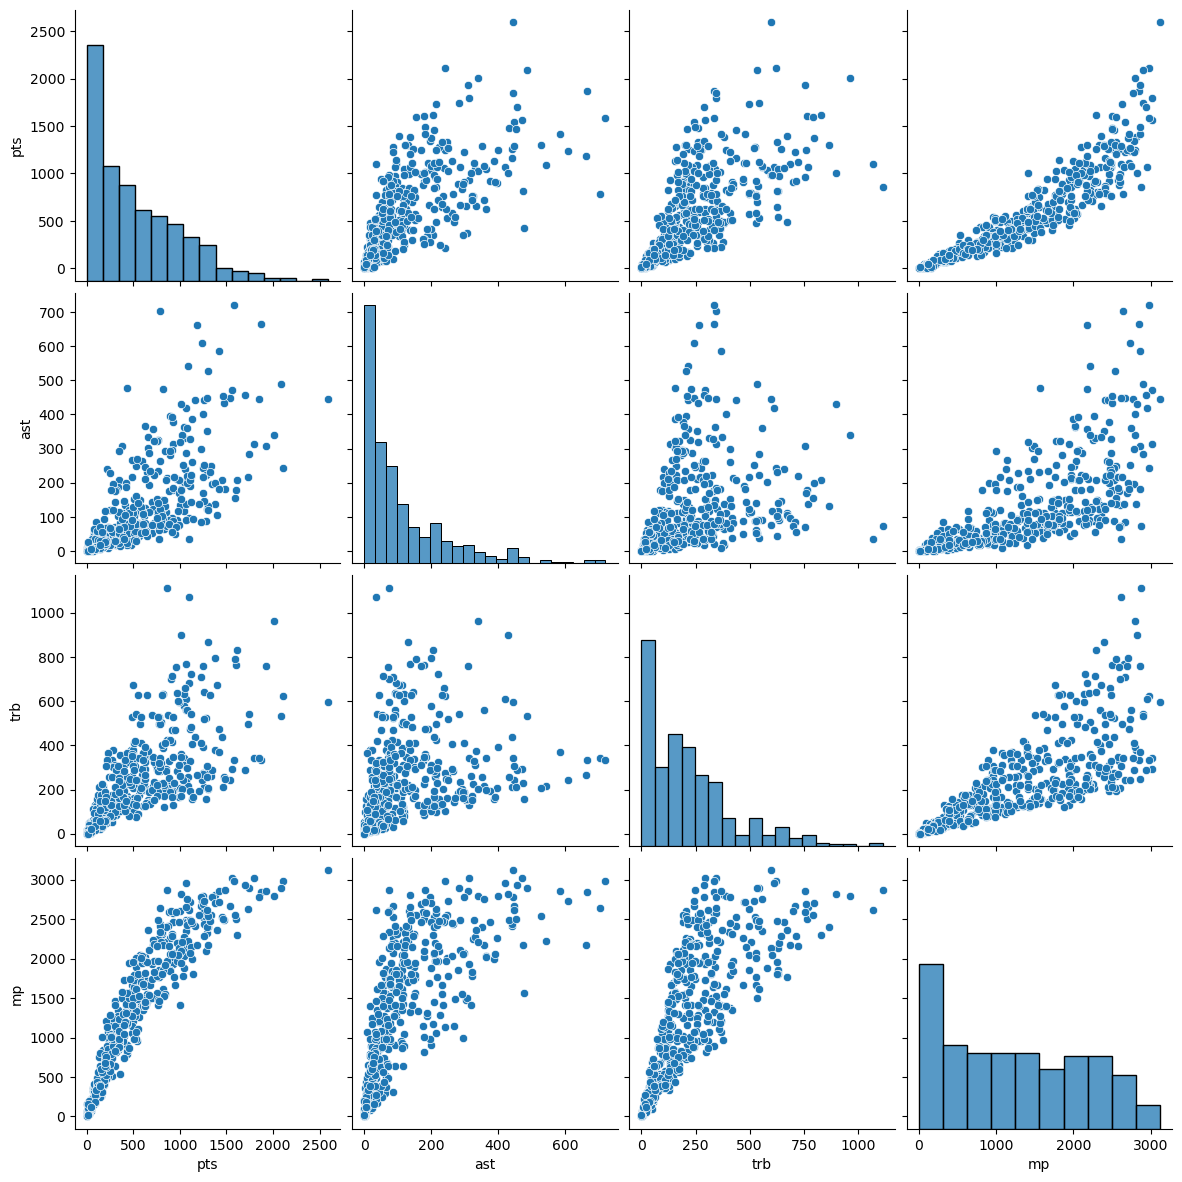

In [115]:
sb.pairplot(df[['pts', 'ast', 'trb', 'mp']], height=3, aspect=1)

## Key Insights (Pairplot Analysis)

- Points (pts) strongly increase with minutes played (mp).
- Assists (ast) and points show a moderate positive relationship.
- Rebounds (trb) have weaker correlation with assists but relate to points.
- Most distributions are right-skewed (many low values, few high values).
- Minutes played (mp) is the key factor influencing all performance metrics.

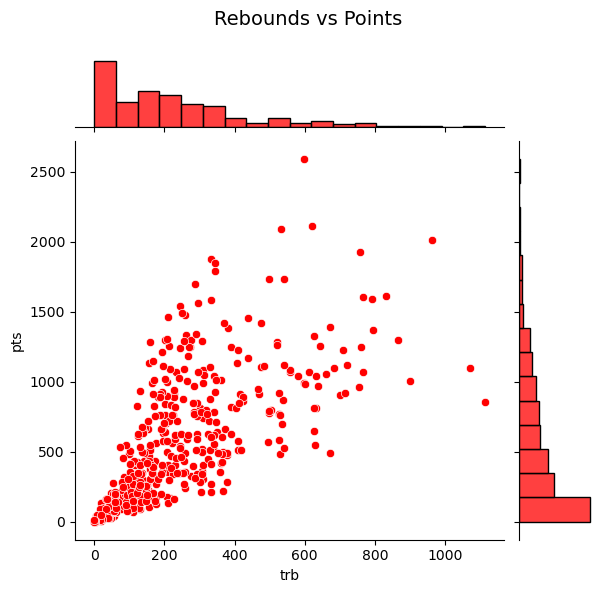

In [121]:
g = sb.jointplot(x='trb', y='pts', data=df, kind='scatter', color='red', height=6)
g.fig.suptitle("Rebounds vs Points", fontsize=14)
g.fig.subplots_adjust(top=0.9)

### (trb vs pts)
 ## Positive trend:
 More rebounds → more points (generally)
 ## Most players:
 Low rebounds (0–300) and low points (0–1000)
 ## Few top players:
 Very high rebounds and points (outliers)
 ## Right-skewed data: 
 Many small values, few very large values
 ## Not perfect relation:
 Some players rebound more but don’t score much
 
 Rebounds help in scoring, but they are not the only factor.

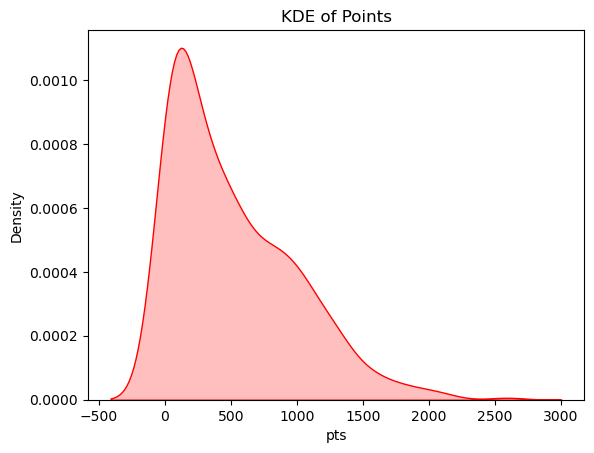

In [123]:
sb.kdeplot(df['pts'], fill=True, color = 'red')
plt.title('KDE of Points')
plt.show()

### KDE of Points
## Right-skewed distribution:
Most players have low points, few have very high points
## Peak around low values:
Highest density near 0–400 points
##Long tail:
Some players score very high (up to ~3000)
## Majority players:
Fall in low to medium scoring range
Top scorers are rare
Most players score fewer points, while only a small number achieve very high scores.